| **ID**| **Name**| 
|-|-|
| 22280075     | Huynh Thao Quynh  | 
| 22280091 | Nguyen Ngoc Thanh Thu  | 

# **Final Project**

## **Problem stament :**     

The widespread dissemination of fake news and propaganda presents serious societal risks, including the erosion of public trust, political polarization, manipulation of elections, and the spread of harmful misinformation during crises such as pandemics or conflicts. From an NLP perspective, detecting fake news is fraught with challenges. Linguistically, fake news often mimics the tone and structure of legitimate journalism, making it difficult to distinguish using surface-level features. The absence of reliable and up-to-date labeled datasets, especially across multiple languages and regions, hampers the effectiveness of supervised learning models. Additionally, the dynamic and adversarial nature of misinformation means that malicious actors constantly evolve their language and strategies to bypass detection systems. Cultural context, sarcasm, satire, and implicit bias further complicate automated analysis. Moreover, NLP models risk amplifying biases present in training data, leading to unfair classifications and potential censorship of legitimate content. These challenges underscore the need for cautious, context-aware approaches, as the failure to address them can inadvertently contribute to misinformation, rather than mitigate it.



Use datasets in link : https://drive.google.com/drive/folders/1mrX3vPKhEzxG96OCPpCeh9F8m_QKCM4z?usp=sharing
to complete requirement.

## **About dataset:**

* **True Articles**:

  * **File**: `MisinfoSuperset_TRUE.csv`
  * **Sources**:

    * Reputable media outlets like **Reuters**, **The New York Times**, **The Washington Post**, etc.

* **Fake/Misinformation/Propaganda Articles**:

  * **File**: `MisinfoSuperset_FAKE.csv`
  * **Sources**:

    * **American right-wing extremist websites** (e.g., Redflag Newsdesk, Breitbart, Truth Broadcast Network)
    * **Public dataset** from:

      * Ahmed, H., Traore, I., & Saad, S. (2017): "Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques" *(Springer LNCS 10618)*



## **Requirement**

A team consisting of three members must complete a project that involves applying the methods learned from the beginning of the course up to the present. The team is expected to follow and document the entire machine learning workflow, which includes the following steps:

1. **Data Preprocessing**: Clean and prepare the dataset,etc.

2. **Exploratory Data Analysis (EDA)**: Explore and visualize the data.

3. **Model Building**: Select and build one or more machine learning models suitable for the problem at hand.

4. **Hyperparameter set up**: Set and adjust the model's hyperparameters using appropriate methods to improve performance.

5. **Model Training**: Train the model(s) on the training dataset.

6. **Performance Evaluation**: Evaluate the trained model(s) using appropriate metrics (e.g., accuracy, precision, recall, F1-score, confusion matrix, etc.) and validate their performance on unseen data.

7. **Conclusion**: Summarize the results, discuss the model's strengths and weaknesses, and suggest possible improvements or future work.





# MY PIPELINE

## **01. Load Data and Preprocessing**

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
from bs4 import BeautifulSoup

# Plotting Libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.porter import PorterStemmer  # same as above, kept for clarity

from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
df = pd.read_parquet("/kaggle/input/nlp-final-project/data_after_preprocess.parquet")

## **02. EDA**

### **Visualize**

## **03. Deep Learning**

In [15]:
def evaluate_model(model_name, y_test, y_pred):
    # Metric
    print(f"----------- {model_name} Model -----------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
    print(f"Precision: {precision_score(y_test, y_pred):.5f}")
    print(f"Recall: {recall_score(y_test, y_pred):.5f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.5f}")

    # Classification report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [17]:
def visualize_loss(model_name, train_loss, val_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'Training vs. Validation Loss - {model_name} Model')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### **3.1. LSTM**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text_ml'], df['label'], test_size=0.2, random_state=42
)

# Phân tích từ hiếm
threshold = 5
tmp_tokenizer = Tokenizer()
tmp_tokenizer.fit_on_texts(X_train)

total_words = len(tmp_tokenizer.word_counts)
rare_words = sum(1 for count in tmp_tokenizer.word_counts.values() if count < threshold)
rare_freq = sum(count for count in tmp_tokenizer.word_counts.values() if count < threshold)
total_freq = sum(tmp_tokenizer.word_counts.values())

print(f"% of rare words in vocabulary: {rare_words / total_words * 100:.2f}%")
print(f"Total coverage of rare words: {rare_freq / total_freq * 100:.2f}%")

% of rare words in vocabulary: 78.88%
Total coverage of rare words: 1.84%


In [5]:
MAX_LEN = 300
embedding_dim = 256
latent_dim = 384

# Tokenizer 
vocab_size = total_words - rare_words
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

# Sequence & padding
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

# Model LSTM
lstm_model = Sequential([
    Embedding(input_dim=vocab_size+1, output_dim=embedding_dim, input_shape=(MAX_LEN,), trainable=True),
    Dropout(0.1),
    LSTM(latent_dim, return_sequences=False),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1750127096.851235     440 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 300, 256)            │      13,292,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 300, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 384)                 │         984,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             385 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,277,249 (54.46 MB)

 Trainable params: 14,277,249 (54.46 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training
epochs=20
batch_size=128

early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/20


I0000 00:00:1750127101.590680     498 cuda_dnn.cc:529] Loaded cuDNN version 90300


443/443 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.6493 - loss: 0.6343 - val_accuracy: 0.6806 - val_loss: 0.5592
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 35s 79ms/step - accuracy: 0.8376 - loss: 0.3817 - val_accuracy: 0.9319 - val_loss: 0.1986
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 35s 79ms/step - accuracy: 0.9443 - loss: 0.1565 - val_accuracy: 0.9534 - val_loss: 0.1317
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.9765 - loss: 0.0728 - val_accuracy: 0.9567 - val_loss: 0.1186
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.9902 - loss: 0.0325 - val_accuracy: 0.9618 - val_loss: 0.1256
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.9957 - loss: 0.0157 - val_accuracy: 0.9613 - val_loss: 0.1438
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 35s 79ms/step - accuracy: 0.9984 - loss: 0.0075 - val_accuracy: 0.9578 - val_loss: 0.1754
Epoch 7: early stopping


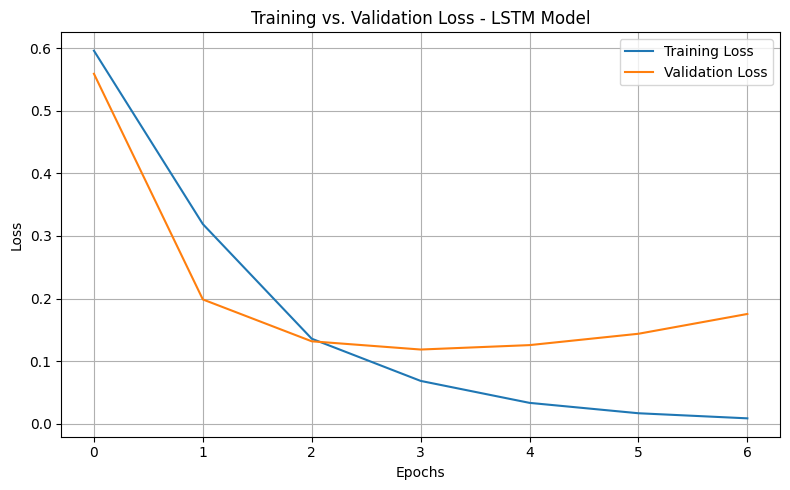

In [18]:
visualize_loss('LSTM', history.history['loss'], history.history['val_loss'])

492/492 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
----------- LSTM Model -----------
Accuracy: 0.95947
Precision: 0.97243
Recall: 0.93567
F1 Score: 0.95370

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      8707
           1       0.97      0.94      0.95      7011

    accuracy                           0.96     15718
   macro avg       0.96      0.96      0.96     15718
weighted avg       0.96      0.96      0.96     15718



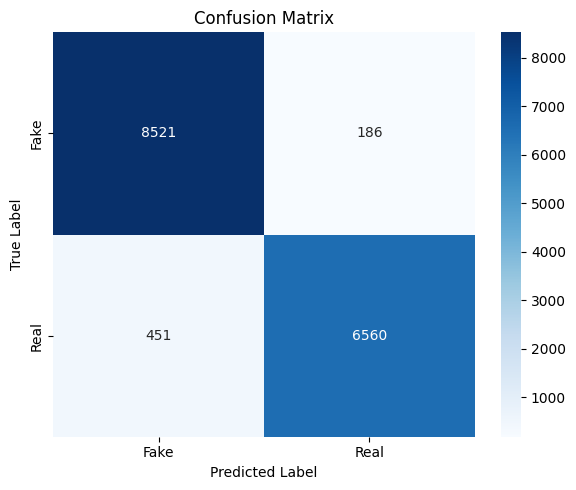

In [19]:
# Dự đoán
y_prob_lstm = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

evaluate_model('LSTM', y_test, y_pred_lstm)

### **3.2. BiLSTM**

### **3.3. CNN - BiLSTM**

## **04. Transformer**